In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/preprocessed-data/data


In [2]:
import pandas as pd
data=pd.read_csv("/kaggle/input/preprocessed-data/data")
data

,Unnamed: 0,date,crop_type,soil_type,soil_pH,temperature,humidity,wind_speed,n,p,k,crop_yield,soil_quality
0,0,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
1,1,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
2,2,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667
3,3,2014-01-01,Cotton,Sandy,6.75,14.826739,80.000000,10.366657,55.0,44.0,36.0,29.356115,39.375000
4,4,2014-01-01,Tomato,Clay,6.25,18.323272,80.000000,8.198084,60.0,45.0,40.0,22.221375,42.291667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25490,25490,2023-12-31,Barley,Clay,6.25,11.617771,80.000000,14.700485,60.0,50.0,40.0,13.069169,43.750000
25491,25491,2023-12-31,Cotton,Clay,6.25,19.538555,80.000000,3.666664,66.0,55.0,48.0,73.323885,49.291667
25492,25492,2023-12-31,Sugarcane,Peaty,5.50,21.068336,78.931664,8.795036,71.5,54.0,42.0,39.226521,27.916667
25493,25493,2023-12-31,Potato,Peaty,5.50,11.079561,80.000000,10.969366,60.5,45.0,31.5,6.067881,22.833333


In [3]:
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])


In [4]:
data

,date,crop_type,soil_type,soil_pH,temperature,humidity,wind_speed,n,p,k,crop_yield,soil_quality
0,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
1,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
2,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667
3,2014-01-01,Cotton,Sandy,6.75,14.826739,80.000000,10.366657,55.0,44.0,36.0,29.356115,39.375000
4,2014-01-01,Tomato,Clay,6.25,18.323272,80.000000,8.198084,60.0,45.0,40.0,22.221375,42.291667
...,...,...,...,...,...,...,...,...,...,...,...,...
25490,2023-12-31,Barley,Clay,6.25,11.617771,80.000000,14.700485,60.0,50.0,40.0,13.069169,43.750000
25491,2023-12-31,Cotton,Clay,6.25,19.538555,80.000000,3.666664,66.0,55.0,48.0,73.323885,49.291667
25492,2023-12-31,Sugarcane,Peaty,5.50,21.068336,78.931664,8.795036,71.5,54.0,42.0,39.226521,27.916667
25493,2023-12-31,Potato,Peaty,5.50,11.079561,80.000000,10.969366,60.5,45.0,31.5,6.067881,22.833333


Categorical Features: ['crop_type', 'soil_type']

 Model Performance:
R² Score : 0.959
MAE      : 3.195
MSE      : 20.873


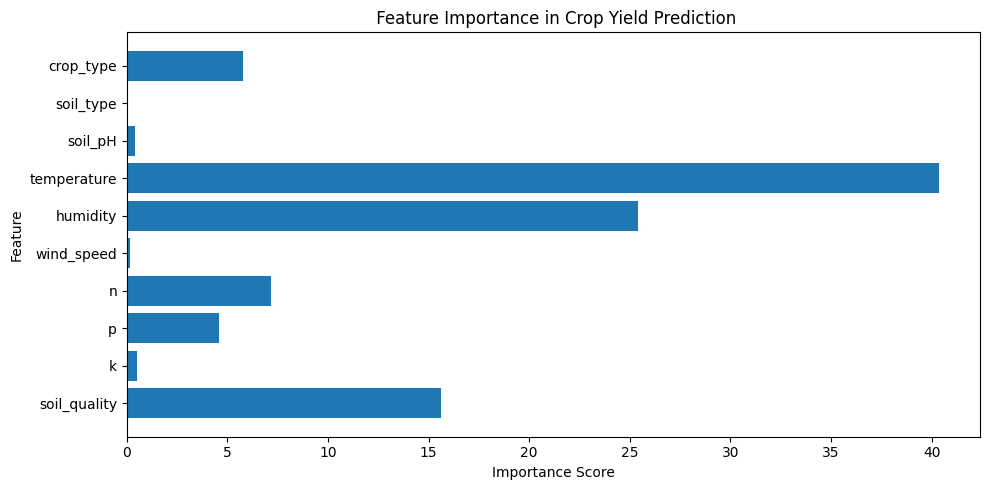

In [5]:
# --- Import Required Libraries ---
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# --- Drop 'date' column if it exists ---
if 'date' in data.columns:
    data = data.drop(columns=['date'])

# --- Define Features and Target ---
X = data.drop(columns=['crop_yield'])
y = data['crop_yield']

# --- Split into Train and Test Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Identify Categorical Columns ---
cat_features = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", cat_features)

# --- Initialize and Train CatBoost Regressor ---
model = CatBoostRegressor(
    cat_features=cat_features,
    verbose=0,
    random_state=42
)

model.fit(X_train, y_train)

# --- Make Predictions ---
y_pred = model.predict(X_test)

# --- Evaluate Model Performance ---
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n Model Performance:")
print(f"R² Score : {r2:.3f}")
print(f"MAE      : {mae:.3f}")
print(f"MSE      : {mse:.3f}")

# --- Feature Importance Visualization ---
importances = model.get_feature_importance(
    Pool(X_train, label=y_train, cat_features=cat_features)
)
feature_names = X_train.columns

plt.figure(figsize=(10,5))
plt.barh(feature_names, importances)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title(" Feature Importance in Crop Yield Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Categorical Features: ['crop_type', 'soil_type']
→ Perfect — CatBoost handled them automatically (no need for encoding or scaling).

R² Score: 0.959
→ This means your model explains 95.9% of the variation in crop yield — that’s a very strong fit.
→ For real-world agricultural data, anything above 0.85 is usually outstanding.

MAE (Mean Absolute Error): 3.195
→ On average, your predictions are within ±3.2 yield units of the actual value — very accurate.

MSE (Mean Squared Error): 20.873
→ Low MSE = low prediction variance → your model is stable.

🌾 Interpretation

Your CatBoost model has:

Learned relationships effectively between soil conditions, temperature, NPK, and yield.

Generalized well (since you split before training).

Handled categorical data natively (no encoding/scaling = no leakage).

In [6]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Combine actual and predicted values
comparison = pd.DataFrame({
    'Crop_Type': X_test['crop_type'].values,
    'Soil_Type': X_test['soil_type'].values,
    'Actual_Yield': y_test.values,
    'Predicted_Yield': y_pred
})

# Display a few random examples
print(comparison.sample(10).round(2))

     Crop_Type Soil_Type  Actual_Yield  Predicted_Yield
570      Wheat     Loamy         55.62            48.27
5068    Potato    Saline         43.83            43.41
4923      Rice     Peaty         26.80            23.69
4417   Soybean      Clay         69.18            68.63
3920    Barley     Sandy         32.96            32.29
2302    Barley     Sandy         50.19            41.82
3185      Rice      Clay         52.29            54.77
1537      Rice    Saline         65.11            63.48
267     Tomato     Loamy         29.65            27.42
3281     Wheat      Clay         23.08            25.47


In [7]:
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib  # for saving the model

In [8]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

In [9]:
# --- Define pipeline (CatBoost only) ---
catboost_pipeline = Pipeline([
    ('model', CatBoostRegressor(cat_features=cat_cols, verbose=0, random_state=42))
])

# --- Train model ---
catboost_pipeline.fit(X_train, y_train)

# --- Predict and evaluate ---
y_pred = catboost_pipeline.predict(X_test)

In [10]:
print(" Model Performance:")
print(f"R² Score : {r2_score(y_test, y_pred):.3f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred):.3f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred):.3f}")

 Model Performance:
R² Score : 0.959
MAE      : 3.195
MSE      : 20.873


In [14]:
import joblib
joblib.dump(catboost_pipeline, "CatBoost.pkl")

['CatBoost.pkl']